In [1]:
import os
os.chdir('../')

In [2]:
import numpy as np
import pandas as pd

data=pd.read_csv('Datasets/employee_survey_clusters.csv')

In [3]:
data.dtypes

employee_id               str
work_life_balance       int64
career_growth           int64
salary_benefits         int64
job_security            int64
work_environment        int64
team_collaboration      int64
training_development    int64
management_support      int64
autonomy_control        int64
recognition_rewards     int64
technology_tools        int64
company_culture         int64
age                     int64
department                str
experience_years        int64
education_level         int64
true_cluster              str
dtype: object

In [4]:
df=data[['work_life_balance','career_growth','salary_benefits','job_security','work_environment','team_collaboration','training_development','management_support','autonomy_control','recognition_rewards','technology_tools','company_culture']]

In [5]:
df.shape

(445, 12)

In [6]:
df.isna().sum()

work_life_balance       0
career_growth           0
salary_benefits         0
job_security            0
work_environment        0
team_collaboration      0
training_development    0
management_support      0
autonomy_control        0
recognition_rewards     0
technology_tools        0
company_culture         0
dtype: int64

In [7]:
data.dtypes

employee_id               str
work_life_balance       int64
career_growth           int64
salary_benefits         int64
job_security            int64
work_environment        int64
team_collaboration      int64
training_development    int64
management_support      int64
autonomy_control        int64
recognition_rewards     int64
technology_tools        int64
company_culture         int64
age                     int64
department                str
experience_years        int64
education_level         int64
true_cluster              str
dtype: object

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# select numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns

scaler = StandardScaler()

data_scaled = data.copy()
data_scaled[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [9]:
data_scaled[data_scaled['employee_id']=='EMP010']['work_environment'].round(4)

9   -0.8239
Name: work_environment, dtype: float64

Assignment 1b

In [12]:
from scipy.spatial.distance import pdist
import numpy as np

euclidean_distances = pdist(data_scaled.select_dtypes(include=[np.number]), metric='euclidean')
print(len(euclidean_distances))

98790


In [13]:
n = data_scaled.shape[0]
print(n*(n-1)//2)

98790


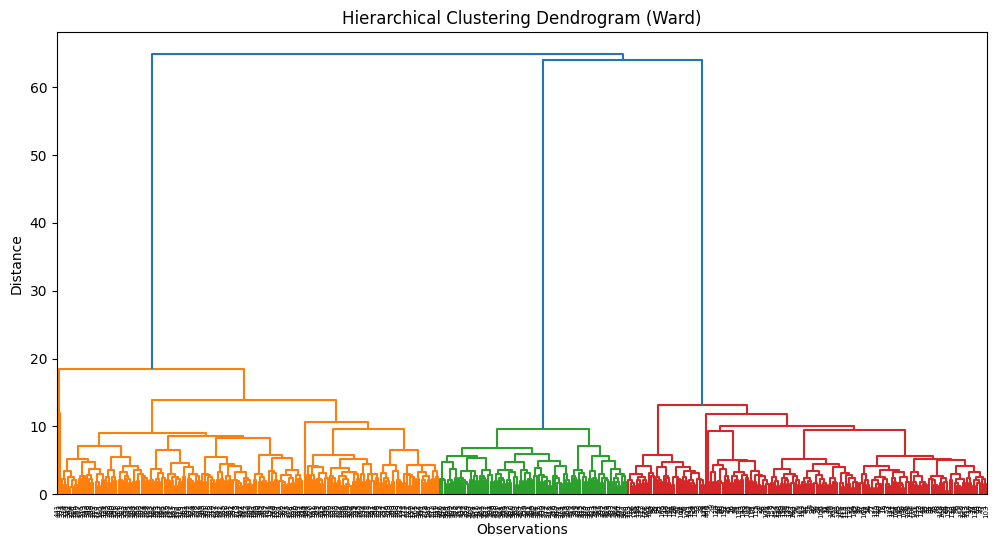

In [14]:
# Question 2

from scipy.cluster.hierarchy import linkage

# Use only numeric columns
data_numeric = data_scaled.select_dtypes(include='number')

# Ward linkage
Z = linkage(data_numeric, method='ward')

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

In [16]:
# Question 3

from scipy.cluster.hierarchy import fcluster
import pandas as pd

# Create 3 clusters
clusters = fcluster(Z, t=3, criterion='maxclust')

# Save cluster memberships (you will need this later)
data_numeric['cluster'] = clusters

# Count number of employees in each cluster
cluster_counts = data_numeric['cluster'].value_counts()

print(cluster_counts)

# Find the smallest cluster size
smallest_cluster = cluster_counts.min()

print("Smallest cluster size:", smallest_cluster)

cluster
1    183
3    172
2     90
Name: count, dtype: int64
Smallest cluster size: 90


In [19]:
#Question 5

# Save memberships
data['cluster'] = clusters

# Smallest cluster
smallest_cluster_label = data['cluster'].value_counts().idxmin()

# Means of numeric columns only
cluster_means = (
    data[data['cluster'] == smallest_cluster_label]
    .select_dtypes(include='number')
    .drop(columns='cluster')
    .mean()
)

print(cluster_means.sort_values(ascending=False))
print("Most important job characteristic:", cluster_means.idxmax())

age                     50.633333
experience_years        18.311111
salary_benefits          6.055556
job_security             6.000000
work_environment         5.977778
team_collaboration       5.088889
recognition_rewards      5.044444
education_level          4.455556
company_culture          4.055556
career_growth            3.144444
technology_tools         3.044444
management_support       2.977778
work_life_balance        2.966667
autonomy_control         2.188889
training_development     2.133333
dtype: float64
Most important job characteristic: age


In [21]:
# Question 6

# Add cluster memberships to the dataset
data['cluster'] = clusters

# Identify the smallest cluster
smallest_cluster_label = data['cluster'].value_counts().idxmin()

# Subset data for the smallest cluster
smallest_cluster_data = data[data['cluster'] == smallest_cluster_label]

# Compute average years of experience
avg_experience = smallest_cluster_data['experience_years'].mean()

print("Average years of experience (smallest cluster):", avg_experience)

Average years of experience (smallest cluster): 18.31111111111111


In [ ]:
# Question 4 and 6 are wrong

In [1]:
round(-0.8238669228968483,4)

-0.8239